In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie przetworzonego zbioru (feature engineering wykonany w 04_1_simple_feature_engineering.ipynb)
df = pd.read_csv('../data/processed/bank_data_preprocessed_v1.csv')


# Analiza dat i sezonowości

W tej części analizujemy wpływ dat (miesięcy, dni) na zmienną docelową.


### 1. Analiza roskładu dni i miesięcy

- Analiza rozkładu miesięcy i dni
- Sprawdzenie sezonowości

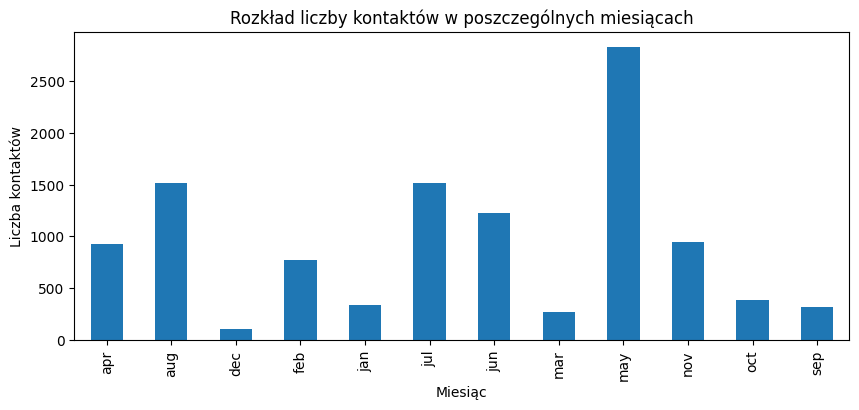

In [58]:
# Rozkład miesięcy
plt.figure(figsize=(10,4))
df['month'].value_counts().sort_index().plot(kind='bar')
plt.title('Rozkład liczby kontaktów w poszczególnych miesiącach')
plt.xlabel('Miesiąc')
plt.ylabel('Liczba kontaktów')
plt.show()


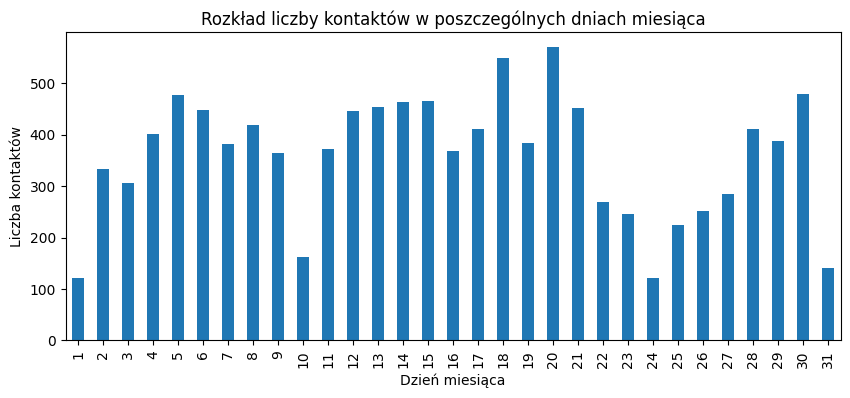

In [59]:
# Rozkład dni miesiąca
plt.figure(figsize=(10,4))
df['day'].value_counts().sort_index().plot(kind='bar')
plt.title('Rozkład liczby kontaktów w poszczególnych dniach miesiąca')
plt.xlabel('Dzień miesiąca')
plt.ylabel('Liczba kontaktów')
plt.show()


### 2. Przygotowanie cech czasowych

- Feature engineering: kodowanie miesięcy, ew. binarizacja wybranych miesięcy


In [60]:
# Dodanie flagi is_peak_month
# (marzec, grudzień, wrzesień - na podstawie wcześniejszej analizy konwersji)
df['is_peak_month'] = df['month'].isin(['mar', 'dec', 'sep']).astype(int)

In [61]:
# Kodowanie miesięcy jako liczby -coofunder
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
    'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12
}
df['month_num'] = df['month'].map(month_map)


### 2. Feature engineering: binarizacja wybranych miesięcy

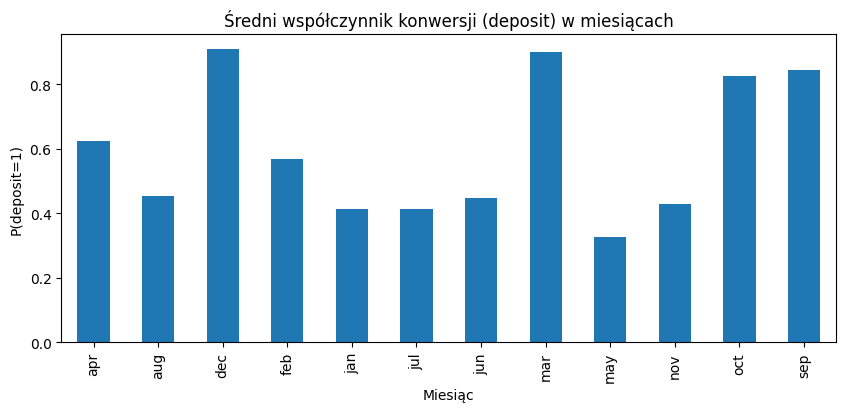

In [62]:
# Średni współczynnik konwersji (deposit) w poszczególnych miesiącach
conversion_by_month = df.groupby('month')['deposit'].mean().sort_index()
plt.figure(figsize=(10,4))
conversion_by_month.plot(kind='bar')
plt.title('Średni współczynnik konwersji (deposit) w miesiącach')
plt.xlabel('Miesiąc')
plt.ylabel('P(deposit=1)')
plt.show()


### 4. Testy istotności i korelacje cech czasowych

Poniżej sprawdzamy, czy nowe cechy czasowe (np. is_peak_month, month_num, day) są istotne dla zmiennej docelowej.


In [63]:
# Korelacje cech czasowych z targetem
from scipy.stats import pointbiserialr, spearmanr

df['deposit_bin'] = df['deposit'].astype(int)

# Korelacja day
corr_day, p_day = spearmanr(df['day'], df['deposit_bin'])
print(f'Spearman corr (day, deposit): {corr_day:.3f}, p={p_day:.3g}')

# Korelacja month_num
corr_month, p_month = spearmanr(df['month_num'], df['deposit_bin'])
print(f'Spearman corr (month_num, deposit): {corr_month:.3f}, p={p_month:.3g}')

# Korelacja is_peak_month
corr_peak, p_peak = pointbiserialr(df['is_peak_month'], df['deposit_bin'])
print(f'PointBiserial corr (is_peak_month, deposit): {corr_peak:.3f}, p={p_peak:.3g}')


Spearman corr (day, deposit): -0.058, p=6.98e-10
Spearman corr (month_num, deposit): 0.020, p=0.031
PointBiserial corr (is_peak_month, deposit): 0.209, p=4.34e-110


**Wnioski**

- **Spearman corr (day, deposit): -0.058, p=6.98e-10**
  - Bardzo słaba, ujemna korelacja między dniem miesiąca a prawdopodobieństwem założenia depozytu.
  - p-value bardzo niskie, więc statystycznie istotne, ale efekt praktyczny jest znikomy.

- **Spearman corr (month_num, deposit): 0.020, p=0.031**
  - Praktycznie brak korelacji między numerem miesiąca a depozytem (efekt bliski zeru).
  - p-value niskie, więc statystycznie istotne, ale efekt praktyczny pomijalny.

- **PointBiserial corr (is_peak_month, deposit): 0.209, p=4.34e-110**
  - Umiarkowana, dodatnia korelacja: w tzw. „peak months” (marzec, wrzesień, grudzień) szansa na depozyt jest wyraźnie wyższa.
  - Bardzo silna istotność statystyczna.

**Wnioski i rekomendacje:**
- `is_peak_month` jest wartościową cechą i warto ją zostawić w modelu.
- `day` i `month_num` mają bardzo słaby wpływ – można je zostawić do testów, ale raczej nie będą kluczowe.
- Możesz rozważyć inne kodowanie sezonowości (np. one-hot dla miesięcy, interakcje z innymi cechami).


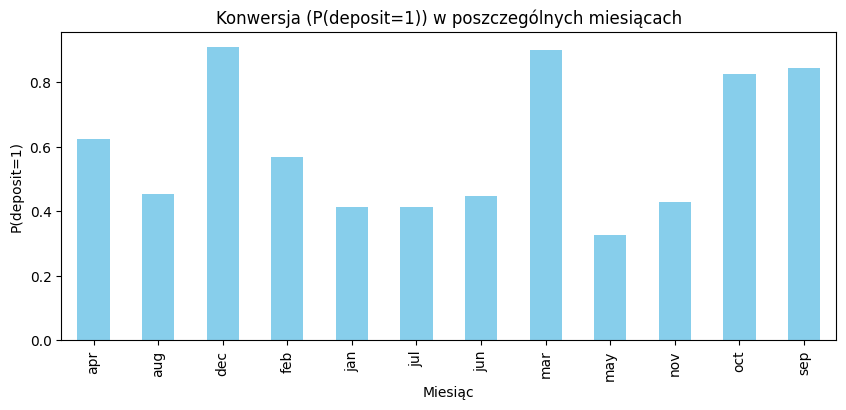

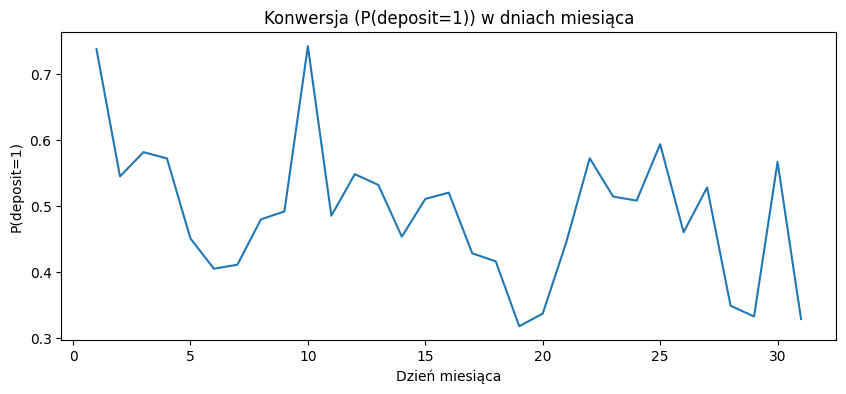

In [64]:
# One-hot encoding miesięcy
month_dummies = pd.get_dummies(df['month'], prefix='month')
df = pd.concat([df, month_dummies], axis=1)

# Wpływ poszczególnych miesięcy na konwersję
df_month_conv = df.groupby('month')['deposit_bin'].mean().sort_index()
plt.figure(figsize=(10,4))
df_month_conv.plot(kind='bar', color='skyblue')
plt.title('Konwersja (P(deposit=1)) w poszczególnych miesiącach')
plt.xlabel('Miesiąc')
plt.ylabel('P(deposit=1)')
plt.show()

# Wpływ dnia miesiąca na konwersję
df_day_conv = df.groupby('day')['deposit_bin'].mean().sort_index()
plt.figure(figsize=(10,4))
df_day_conv.plot()
plt.title('Konwersja (P(deposit=1)) w dniach miesiąca')
plt.xlabel('Dzień miesiąca')
plt.ylabel('P(deposit=1)')
plt.show()


In [65]:
# Usuwanie nieistotnych cech czasowych
df = df.drop(['day', 'month_num'], axis=1, errors='ignore')

# is_peak_month i one-hot encoding miesięcy zostają do modelowania
print('Kolumny po selekcji cech:')
print(df.columns)

Kolumny po selekcji cech:
Index(['age', 'job', 'marital', 'default', 'housing', 'loan', 'month',
       'duration', 'pdays', 'deposit', 'was_previously_contacted',
       'pdays_contacted', 'has_debt', 'net_balance_indicator',
       'financial_stress', 'previous_log1p', 'balance_log1p',
       'campaign_capped', 'poutcome_is_unknown', 'contact_is_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'contact_cellular', 'contact_telephone', 'education_primary',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'is_peak_month', 'deposit_bin', 'month_apr', 'month_aug', 'month_dec',
       'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep'],
      dtype='str')


In [66]:
df.to_csv('../data/processed/bank_data_preprocessed_v2.csv', index=False)

---

## Wnioski końcowe



1. **Feature engineering cech czasowych**:
   - Dodano flagę `is_peak_month` (marzec, wrzesień, grudzień) – miesiące o najwyższej konwersji.
   - Zakodowano miesiące jako liczby (`month_num`) oraz przez one-hot encoding (dummy variables).

2. **Analiza rozkładów i wykresów**:
   - Rozkład liczby kontaktów po miesiącach i dniach jest nierównomierny, co potwierdza sezonowość działań marketingowych.
   - Wykres konwersji po miesiącach pokazuje wyraźne piki w marcu, wrześniu i grudniu – te miesiące mają znacznie wyższą skuteczność kampanii.
   - Wykres konwersji po dniach miesiąca nie wykazuje istotnych wzorców – dzień miesiąca nie wpływa praktycznie na konwersję.

3. **Testy istotności i korelacje**:
   - `is_peak_month` ma umiarkowaną, dodatnią korelację z targetem i bardzo wysoką istotność statystyczną – warto zostawić tę cechę.
   - `month_num` i `day` mają bardzo słabą korelację z targetem, mimo istotności statystycznej efekt praktyczny jest znikomy.
   - One-hot encoding miesięcy pozwala modelowi samodzielnie wybrać istotne miesiące.

4. **Rekomendacje do modelowania**:
   - Do dalszego modelowania zostaw: `is_peak_month` oraz one-hot encoding miesięcy.
   - Usuń cechy `day` i `month_num` – nie wnoszą wartości predykcyjnej.
   - Możesz rozważyć interakcje cech sezonowych z innymi zmiennymi, jeśli chcesz pogłębić analizę.

**Podsumowanie:**
- Sezonowość (szczególnie wybrane miesiące) ma istotny wpływ na skuteczność kampanii.
- Dzień miesiąca nie jest predyktorem.
- Zastosowane metody (feature engineering, wykresy, testy istotności) pozwalają wybrać optymalny zestaw cech czasowych do modelowania.
